La parte de preparar los datos es igual que en RNN, por ello no está explicado en este notebook, pero si en RNN-ADNE.ipynb

#### IMPORTAR LIBRERIAS Y PREPARACIÓN DE LOS DATOS

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from gensim.models import KeyedVectors
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import re
import gensim.downloader as api
from keras.layers import LSTM
import torch
from transformers import pipeline
from datasets import load_dataset
from transformers import AutoTokenizer, GPT2LMHeadModel, DataCollatorForLanguageModeling, Trainer, TrainingArguments, GPT2Tokenizer
from tensorflow.keras.models import load_model


In [23]:
def limpiar_agencia(texto):
    return re.sub(r'^[A-Z\s/\-]+ \([A-Za-z]+\)\s*[-–—]\s*', '', texto)

In [24]:
df_true = pd.read_csv('data/True.csv')
df_fake = pd.read_csv('data/Fake.csv')

df_true['output'] = 'True'
df_fake['output'] = 'Fake'

data = pd.concat([df_true, df_fake], ignore_index=True)
data = data.drop_duplicates()

data['text'] = data['text'].astype(str).apply(limpiar_agencia)

data.head()

,title,text,subject,date,output
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction ...,politicsNews,"December 31, 2017",True
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fir...,politicsNews,"December 29, 2017",True
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links bet...,politicsNews,"December 31, 2017",True
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos tol...,politicsNews,"December 30, 2017",True
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Post...,politicsNews,"December 29, 2017",True


In [25]:
# Extraer variables
X1 = data['text'].astype(str)
y = np.array(data['output'])

In [26]:
# Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X1 )

# Secuencias numéricas
sequences1 = tokenizer.texts_to_sequences(X1)

# Padding
max_len = 5000
X1_padded = pad_sequences(sequences1, maxlen=max_len)

In [27]:
# Dividir
X1_train, X1_val, y_train, y_val = train_test_split(
    X1_padded, y, test_size=0.25, random_state=42)

# Convertir y a binario
y_train = np.where(y_train == "Fake", 0, 1).astype(np.float32)
y_val = np.where(y_val == "Fake", 0, 1).astype(np.float32)

In [28]:
# Carga automática del modelo preentrenado desde gensim
w2v_model = api.load("word2vec-google-news-300")
print(w2v_model['king'][:10])

[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125]


In [29]:
# Crear embedding matrix
embedding_dim = 300
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]
    else:
        embedding_matrix[i] = np.random.normal(0, 0.1, embedding_dim)

# Capa embedding con pesos preentrenados
from tensorflow.keras.layers import Embedding
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)

#### ENTRENAR MODELO

In [ ]:
# Modelo
input1 = Input(shape=(max_len,))
embedding1 = embedding_layer(input1)
lstm1 = LSTM(64)(embedding1)

dense1 = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(lstm1)
output = Dense(1, activation="sigmoid")(dense1)

model_clasificador = Model(inputs=input1, outputs=output)
model_clasificador.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'modelo_LSTM_Word2Vec.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

model_clasificador.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 5000, 300)      │    41,403,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,501,265 (158.31 MB)

 Trainable params: 97,665 (381.50 KB)

 Non-trainable params: 41,403,600 (157.94 MB)

In [ ]:
# Entrenamiento
history = model_clasificador.fit(
    [X1_train],
    y_train,
    epochs=10,
    batch_size=256,
    validation_data=(X1_val, y_val),
    callbacks=[early_stop, checkpoint])

Epoch 1/10


/Users/blancasl01/miniconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 5000))',)
  warnings.warn(msg)


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8397 - loss: 0.4493
Epoch 1: val_loss improved from inf to 0.19134, saving model to modelo_LSTM_Word2Vec.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 684s 5s/step - accuracy: 0.8401 - loss: 0.4483 - val_accuracy: 0.9460 - val_loss: 0.1913
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9429 - loss: 0.2034
Epoch 2: val_loss improved from 0.19134 to 0.14190, saving model to modelo_LSTM_Word2Vec.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 863s 7s/step - accuracy: 0.9430 - loss: 0.2032 - val_accuracy: 0.9610 - val_loss: 0.1419
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9279 - loss: 0.2194
Epoch 3: val_loss did not improve from 0.14190
131/131 ━━━━━━━━━━━━━━━━━━━━ 823s 6s/step - accuracy: 0.9278 - loss: 0.2196 - val_accuracy: 0.9465 - val_loss: 0.1766
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9501 - loss: 0.1587
Epoch 4: val_loss did not improve from 0.14190
131/131 ━━━━━━━━━━━━━━━━━━━━ 999s 8s/

In [38]:
# Evaluación del modelo
results = model_clasificador.evaluate([X1_val], y_val)
# Mostrar resultados
print(f"Test Loss: {results[0]}, Test Accuracy: {results[1]}")

/Users/blancasl01/miniconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(None, 5000))',)
  warnings.warn(msg)


350/350 ━━━━━━━━━━━━━━━━━━━━ 211s 603ms/step - accuracy: 0.9618 - loss: 0.1393
Test Loss: 0.1419026404619217, Test Accuracy: 0.9609773755073547


A partir de la época 3 vemos que la loss empieza a aumentar, por lo que se activa early stopping, deteniendon el entrenamiento y restaurando el modelo con los pesos de la mejor época, la 2. Una vez entrenado el modelo, lo evaluamos sobre datos no vistos (test set), obteniendo una accuracy del 0.9618 y una loss de 0.139. Esto confirma que el modelo generaliza muy bien, y no ha sobreajustado a los datos de entrenamientom ya que los resultados del conjunto de test son prácticamente idénticos a los de validación en la mejor época. El modelo ha demostrado un rendimiento muy alto tanto en validación como en test.

#### VISUALIZAR RESULTADOS

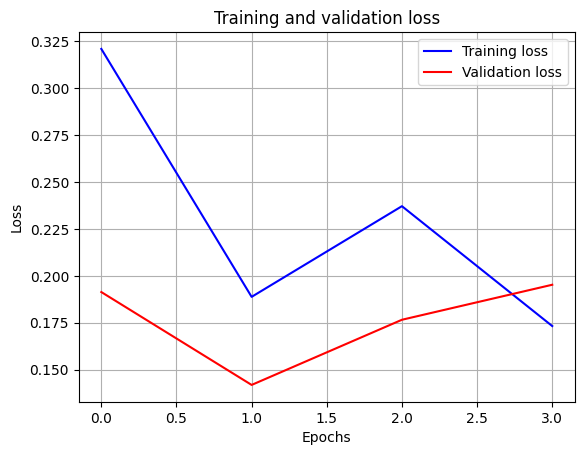

In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.plot(history.history['val_loss'], color='red', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

En esta gráfica vemos cómo evoluciona la pérdida (loss) del modelo en entrenamiento y validación a lo largo de las épocas. Observamos que la de validación disminuye notablemente durante las primeras épocas, alcanzando su mínimo en la época 1, lo que coincide con los resultados obtenidos anteriormente. A partir de ahí, la pérdida vuelve a aumentar ligeramente, lo que sugiere un posible inicio de sobreajuste.

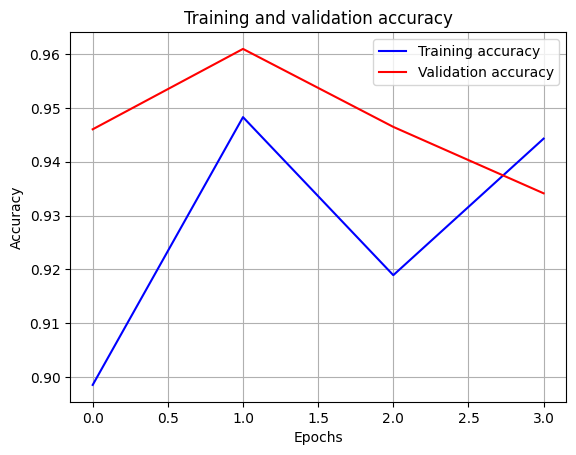

In [40]:
plt.plot(history.history['accuracy'], color='blue', label='Training accuracy')
plt.plot(history.history['val_accuracy'], color='red', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

En esta gráfica vemos la accuracy del modelo en ambos conjuntos. La precisión mejora durante las primeras dos épocas y alcanza un valor máximo en la época 1 para validación, que es donde también se logra el mejor rendimiento general. A partir de esa época, la precisión de validación empieza a bajar, mientras que la de entrenamiento sigue mejorando, lo que sugiere sobreajuste.

/Users/blancasl01/miniconda3/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(None, 5000))',)
  warnings.warn(msg)


350/350 ━━━━━━━━━━━━━━━━━━━━ 199s 570ms/step


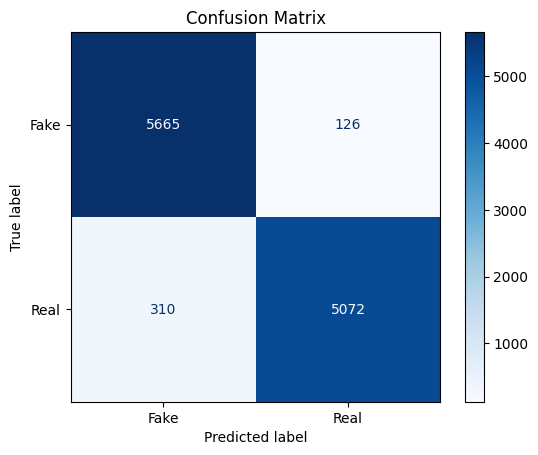

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
y_pred_prob = model_clasificador.predict([X1_val])
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

La matriz de confusión muestra el rendimiento del modelo sobre el conjunto de test. Vemos que tiene muy pocos errores, especialmente con las noticias falsas (False Negatives muy bajos), lo que hace que sea una herramienta útil para detectar desinformación.

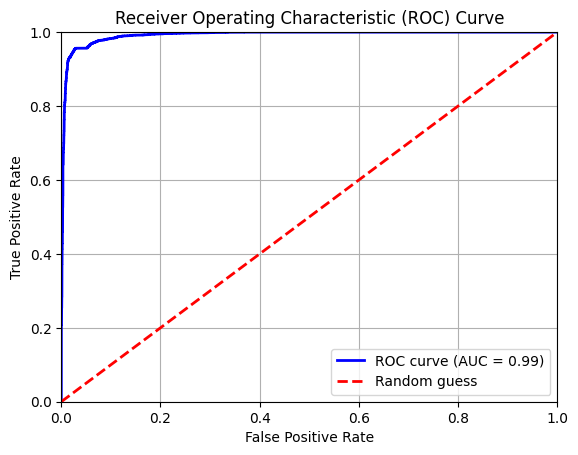

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
auc_score = roc_auc_score(y_val, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Esta curva nos muestra la tasa de verdaderos positivos frente a falsos positivos, el AUC es de 0.99, lo que indica muy buen rendimiento, así como la curva ajustada casi perfectamente a la esquina superior izquierda. Esto muestra una alta discriminación entre noticias falsas y reales.

#### COMPROBAMOS EL MODELO

Probamos ahora con una noticia falsa y una real el modelo, en este caso vemos que funciona correctamente, clasificando bien ambas.

In [44]:

fake_body = (
    "In a bizarre twist straight out of a science fiction movie, an anonymous source has leaked classified documents "
    "allegedly revealing the existence of an alien base located beneath the Eiffel Tower in Paris. The source claims that "
    "during a routine maintenance check in early 2023, underground scanners picked up unexplained electromagnetic activity "
    "that led to the discovery of a hidden chamber. Inside, maintenance workers allegedly found strange equipment, symbols "
    "not of any known language, and even signs of biological organisms that emit light. The beings, reportedly resembling "
    "tall humanoid figures with elongated limbs, are said to have been living undetected for decades and use advanced "
    "technology to avoid human detection. Despite repeated inquiries from journalists and independent researchers, French "
    "government officials have refused to comment on the matter. Conspiracy theorists argue that world governments have "
    "known about extraterrestrial life for years and are now working together to suppress this new revelation. No physical "
    "evidence has yet been presented to the public, and mainstream scientists have dismissed the claims as a hoax. However, "
    "online forums and social media are buzzing with speculation, and some Parisians have reported unusual activity near the landmark at night."
)


In [45]:

true_body = (
    "Steve Bannon, a former top White House strategist and a former chief campaign aide to Donald Trump, "
    "has been asked to testify before the U.S. House of Representatives intelligence panel next month, Bloomberg News reported. "
    "Corey Lewandowski, Trump’s former campaign manager, was also asked to testify in early January, Bloomberg reported on Friday, "
    "citing an official familiar with the committee’s schedule. "
    "Representatives for the committee did not immediately respond to inquiries for comment. "
    "The panel is probing alleged Russian meddling into the 2016 U.S. election."
)





In [47]:
def predict_news(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    prob = model_clasificador.predict(padded)[0][0]
    label = "Real" if prob > 0.5 else "Fake"
    print(f"Predicted: {label} (Probability: {prob:.4f})")
predict_news(true_body)
predict_news(fake_body)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Predicted: Real (Probability: 0.9238)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Predicted: Fake (Probability: 0.2638)
